<a href="https://colab.research.google.com/github/safosaffers/4C_8S_AdMap_VN/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

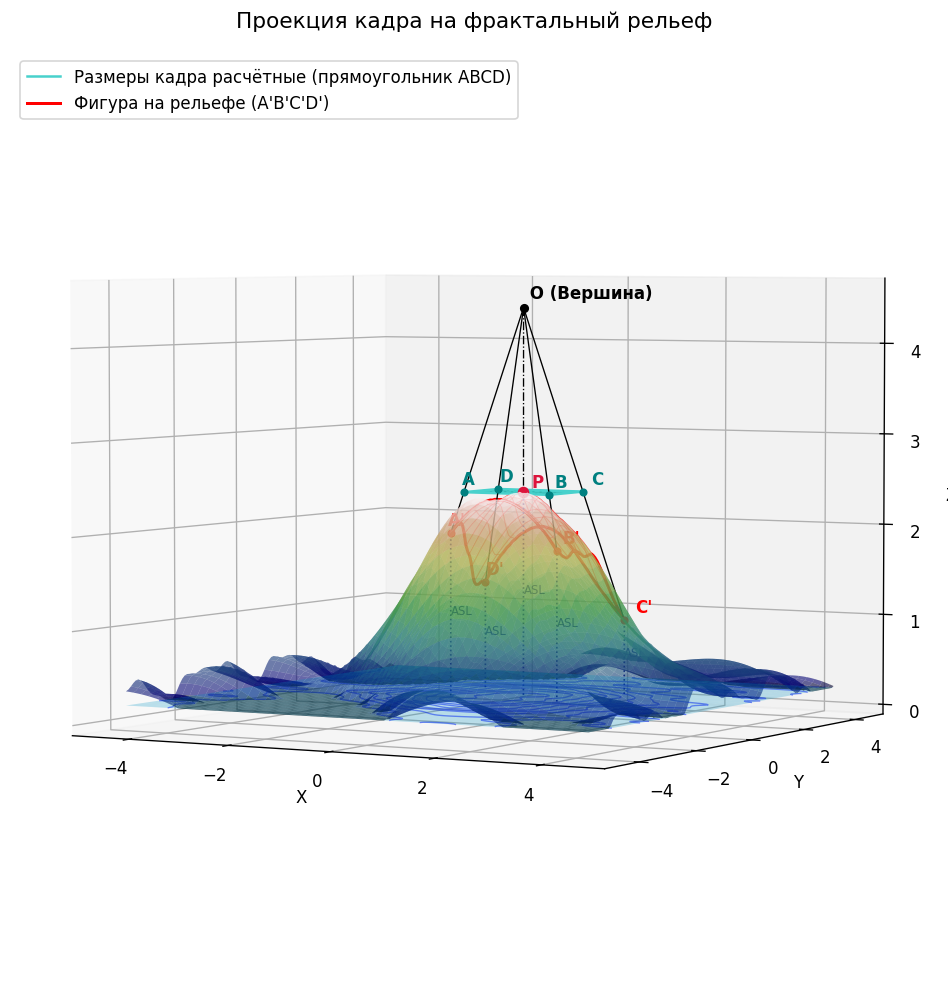

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator


# -----------------------------------------------------------------------------
# ПАРАМЕТРЫ
# -----------------------------------------------------------------------------
grid_size = 120
x_min, x_max = -4.5, 4.5
y_min, y_max = -4.5, 4.5
z_water = 0.2

w = 0.85
h_frame = 0.60
h_apex = 2.0

n_hatch = 10


# -----------------------------------------------------------------------------
# РЕЛЬЕФ
# -----------------------------------------------------------------------------
x = np.linspace(x_min, x_max, grid_size)
y = np.linspace(y_min, y_max, grid_size)
X, Y = np.meshgrid(x, y)

np.random.seed(101)


def fractal_hill(X, Y, octaves=5):
    Z = 2.4 * np.exp(-(X**2 + Y**2) / 6.0)

    for i in range(octaves):
        freq = 0.7 * 1.9**i
        amp = 0.35 / 1.8**i

        angle = np.random.uniform(0, 2 * np.pi)
        phase = np.random.uniform(0, 2 * np.pi)

        Z += amp * np.sin(
            freq * np.cos(angle) * X
            + freq * np.sin(angle) * Y
            + phase
        )

    return Z


Z = np.maximum(fractal_hill(X, Y), z_water)


# -----------------------------------------------------------------------------
# ПИК РЕЛЬЕФА
# -----------------------------------------------------------------------------
max_idx = np.unravel_index(np.argmax(Z), Z.shape)

P = np.array([
    X[max_idx],
    Y[max_idx],
    Z[max_idx],
])

O = P + [0, 0, h_apex]


# -----------------------------------------------------------------------------
# ПЕРЕСЕЧЕНИЕ ЛУЧА С РЕЛЬЕФОМ
# -----------------------------------------------------------------------------
interp_Z = RegularGridInterpolator((y, x), Z)


def intersect_ray(O, V):
    """Продолжает луч O -> V за точку V и ищет ближайшее пересечение с рельефом."""
    t = np.linspace(1.0, 3.5, 600)
    pts = O + t[:, None] * (V - O)

    valid = (
        (pts[:, 0] >= x_min) & (pts[:, 0] <= x_max) &
        (pts[:, 1] >= y_min) & (pts[:, 1] <= y_max)
    )

    pts = pts[valid]

    if len(pts) == 0:
        raise ValueError("Луч вышел за пределы модели рельефа.")

    terrain_z = interp_Z(pts[:, [1, 0]])
    idx = np.argmin(np.abs(pts[:, 2] - terrain_z))

    return pts[idx]


# -----------------------------------------------------------------------------
# ПЛОСКИЙ КАДР ABCD
# -----------------------------------------------------------------------------
x_peak, y_peak, z_peak = P

frame = np.array([
    [x_peak - w, y_peak - h_frame, z_peak],  # A
    [x_peak + w, y_peak - h_frame, z_peak],  # B
    [x_peak + w, y_peak + h_frame, z_peak],  # C
    [x_peak - w, y_peak + h_frame, z_peak],  # D
])

A, B, C, D = frame

projected = np.array([intersect_ray(O, p) for p in frame])
A_p, B_p, C_p, D_p = projected

P_p = intersect_ray(O, P)


# -----------------------------------------------------------------------------
# ПРОЕЦИРОВАНИЕ ЛИНИЙ
# -----------------------------------------------------------------------------
def project_line(p1, p2, samples=20):
    p1 = np.array(p1)
    p2 = np.array(p2)
    points = [
        intersect_ray(O, p1 + t * (p2 - p1))
        for t in np.linspace(0, 1, samples)
    ]
    return np.array(points)


def project_boundary(points, samples_per_edge=40):
    boundary = []

    for p1, p2 in zip(points, np.roll(points, -1, axis=0)):
        for t in np.linspace(0, 1, samples_per_edge, endpoint=False):
            boundary.append(
                intersect_ray(O, p1 + t * (p2 - p1))
            )

    boundary.append(boundary[0])
    return np.array(boundary)


red_boundary = project_boundary(frame)


# -----------------------------------------------------------------------------
# ОТРИСОВКА
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(12, 10), dpi=120)
ax = fig.add_subplot(111, projection="3d")


# Рельеф
ax.plot_surface(
    X, Y, Z,
    cmap="gist_earth",
    alpha=0.6,
    edgecolor="none",
    rstride=2,
    cstride=2,
)


# Вода
X_w, Y_w = np.meshgrid(
    np.linspace(x_min, x_max, 20),
    np.linspace(y_min, y_max, 20),
)
Z_w = np.full_like(X_w, z_water)

ax.plot_surface(
    X_w, Y_w, Z_w,
    color="deepskyblue",
    alpha=0.25,
)

ax.contour(
    X, Y, Z,
    levels=8,
    zdir="z",
    offset=z_water,
    colors="blue",
    linewidths=0.8,
    alpha=0.5,
)


# -----------------------------------------------------------------------------
# СЕТКА ПЛОСКОГО КАДРА И ЕЁ ПРОЕКЦИЯ
# -----------------------------------------------------------------------------
u_grid = np.linspace(-w, w, n_hatch)
v_grid = np.linspace(-h_frame, h_frame, n_hatch)


def draw_frame_line(p1, p2):
    """Линия на плоском кадре + её проекция на рельеф."""
    ax.plot(
        *np.array([p1, p2]).T,
        color="lightseagreen",
        lw=0.6,
        alpha=0.6,
    )

    projected_line = project_line(p1, p2)

    ax.plot(
        *projected_line.T,
        color="red",
        lw=0.6,
        alpha=0.6,
    )


# Вертикальные линии кадра
for u in u_grid:
    draw_frame_line(
        [x_peak + u, y_peak - h_frame, z_peak],
        [x_peak + u, y_peak + h_frame, z_peak],
    )

# Горизонтальные линии кадра
for v in v_grid:
    draw_frame_line(
        [x_peak - w, y_peak + v, z_peak],
        [x_peak + w, y_peak + v, z_peak],
    )


# -----------------------------------------------------------------------------
# ОСНОВНЫЕ КОНТУРЫ
# -----------------------------------------------------------------------------
frame_closed = np.vstack([frame, frame[0]])

ax.plot(
    *frame_closed.T,
    color="mediumturquoise",
    lw=1.5,
    label="Размеры кадра расчётные (прямоугольник ABCD)",
)

# Диагонали
ax.plot(
    *np.array([A, C]).T,
    color="mediumturquoise",
    lw=0.8,
    ls="--",
)

ax.plot(
    *np.array([B, D]).T,
    color="mediumturquoise",
    lw=0.8,
    ls="--",
)


# Проекция границы кадра
ax.plot(
    *red_boundary.T,
    color="red",
    lw=1.8,
    label="Фигура на рельефе (A'B'C'D')",
)


# Лучи пирамиды
for point in projected:
    ax.plot(
        *np.array([O, point]).T,
        color="black",
        lw=0.8,
    )


# Центральная ось
ax.plot(
    *np.array([O, P_p]).T,
    color="black",
    lw=0.8,
    ls="-.",
)


# -----------------------------------------------------------------------------
# ТОЧКИ И ПОДПИСИ
# -----------------------------------------------------------------------------
ax.scatter(*O, color="black", s=20)
ax.scatter(*P, color="crimson", s=35, zorder=10)


def mark_points(points, labels, color):
    for pt, label in zip(points, labels):
        ax.scatter(*pt, color=color, s=15)
        ax.text(
            pt[0] * 1.08,
            pt[1] * 1.08,
            pt[2] + 0.08,
            label,
            color=color,
            fontsize=10,
            fontweight="bold",
        )


mark_points(frame, ["A", "B", "C", "D"], "teal")
mark_points(projected, ["A'", "B'", "C'", "D'"], "red")

ax.text(
    O[0], O[1], O[2] + 0.1,
    " O (Вершина)",
    color="black",
    fontsize=10,
    fontweight="bold",
)

ax.text(
    P[0] + 0.1,
    P[1] + 0.1,
    P[2] + 0.05,
    "P",
    color="crimson",
    fontsize=10,
    fontweight="bold",
)


# -----------------------------------------------------------------------------
# ВЫСОТЫ ASL
# -----------------------------------------------------------------------------
for pt in np.vstack([projected, P_p]):
    ax.plot(
        [pt[0], pt[0]],
        [pt[1], pt[1]],
        [z_water, pt[2]],
        color="navy",
        ls=":",
        lw=1.0,
    )

    ax.text(
        pt[0],
        pt[1],
        (z_water + pt[2]) / 2,
        "ASL",
        color="navy",
        fontsize=7,
    )


# -----------------------------------------------------------------------------
# ВИД
# -----------------------------------------------------------------------------
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.grid(True)

# Вид со стороны
ax.view_init(elev=3.2, azim=-60)
# Надир:
# ax.view_init(elev=90, azim=-90)

ax.set_title(
    "Проекция кадра на фрактальный рельеф",
    fontsize=13,
    pad=15,
)

ax.legend(loc="upper left")

plt.savefig(
    "fractal_projection_scene.png",
    bbox_inches="tight",
    dpi=150,
)

plt.show()